Supplementary Code S3 — Benchmark summary, OOF performance, and reporting plots

**Purpose**

This notebook generates a consolidated, publication-ready summary of the nested cross-validation
benchmarking results produced in Supplementary Code S2. Using out-of-fold (OOF) predictions
exclusively, it provides unbiased estimates and visualizations of model discrimination,
calibration-related performance, and result stability across predefined feature-set variants
(FULL, CLINICAL, and BIOMARKERS).

The script is strictly post hoc: no model fitting, hyperparameter tuning, or feature selection is
performed at this stage.


**Reporting standard and methodological principles**

The workflow adheres to current best practices for transparent reporting of internally validated
clinical and translational machine-learning models, including recommendations from
TRIPOD-AI and PROBAST-AI:

Exclusive use of out-of-fold predictions for all reported performance metrics and curves,
ensuring unbiased evaluation and avoiding optimistic bias.

Aggregation across outer cross-validation folds to quantify both central tendency and
variability of model performance.

Reporting of complementary performance dimensions, including:

discrimination (ROC AUC, precision–recall AUC),

probabilistic accuracy (Brier score),

prevalence-aware interpretation of precision–recall curves.

Quantification of uncertainty using stratified, patient-level bootstrap confidence intervals
for OOF ROC AUC and PR-AUC.

Explicit visualization of class imbalance effects via prevalence baselines in
precision–recall plots.

Strict separation between model development (S2) and reporting (S3), with no refitting of
models on the full dataset at any stage.

Fully scripted generation of all tables and figures to ensure reproducibility and auditability.

**Inputs**

The script expects the output artifacts generated by Supplementary Code S2, typically located in
/results/S2_nestedcv (or /content/results/S2_nestedcv in Google Colab), including:

- nestedcv_results_all_variants.csv
Outer-fold performance metrics across feature-set variants and models.

- nestedcv_oof_probs_all_variants.csv
Out-of-fold predicted probabilities with corresponding true labels.

- winner_model_by_variant.csv
Model selected as best-performing per feature-set variant based on mean outer-fold ROC AUC.

- Optional (used when present):

  - oof_calibration_summary.csv

  - oof_calibration_curve.csv

  - oof_dca_curves.csv

The script automatically detects column schemas to ensure robustness against minor naming changes
across experiments.

**Outputs**

All outputs are written to a dedicated S3 results directory, organized into subfolders:

-tables/

1. fold_metrics_summary_by_variant_model.csv
Mean and standard deviation of outer-fold metrics by variant and model.

2. winner_oof_metrics_with_bootstrap_ci.csv
OOF discrimination metrics for the winning model per variant, with 95% bootstrap confidence
intervals.

3. Copies of calibration and decision-curve tables from S2 (when available).


- figures/

1. Fold-wise boxplots of ROC AUC, PR-AUC, and Brier score by variant and model.

2. OOF ROC curves for the winning model per variant.

3. OOF precision–recall curves with prevalence baselines for the winning model per variant.

- logs/

1. Schema-detection and execution metadata supporting transparent auditing and reproducibility.

All figures are saved in publication-ready resolution.

**Role in the analysis pipeline**

Supplementary Code S2 performs leakage-safe model training, hyperparameter optimization, and
unbiased performance estimation using nested cross-validation.
Supplementary Code S3 serves as the reporting and synthesis layer, translating S2 outputs
into interpretable tables and figures suitable for manuscript presentation.

By relying exclusively on out-of-fold predictions and avoiding any model refitting or data reuse,
this step preserves the integrity of internal validation and provides a transparent foundation for
subsequent analyses (Supplementary Codes S4–S11, including calibration refinement,
interpretability, and robustness assessments).

## Imports + helpers

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)


## Notebook display helpers

In [2]:
def _in_notebook() -> bool:
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            return False
        return "IPKernelApp" in ip.config
    except Exception:
        return False

def _display_df(df: pd.DataFrame, title: str, n: int = 10) -> None:
    if not _in_notebook():
        return
    try:
        from IPython.display import display, Markdown
        display(Markdown(f"### {title}"))
        display(df.head(n))
    except Exception:
        pass

def _display_image(path: Path, title: str = "") -> None:
    if not _in_notebook():
        return
    try:
        from IPython.display import display, Markdown, Image
        if title:
            display(Markdown(f"### {title}"))
        display(Image(filename=str(path)))
    except Exception:
        pass

def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)


## Resolve input S2 directory + define output directories

In [3]:

S2_DIR = Path("/content/")

req = [
    "nestedcv_results_all_variants.csv",
    "nestedcv_oof_probs_all_variants.csv",
    "winner_model_by_variant.csv",
]
missing = [fn for fn in req if not (S2_DIR / fn).exists()]
if missing:
    raise FileNotFoundError(f"Missing required S2 files in {S2_DIR}: {missing}")

print("Using S2_DIR:", S2_DIR.resolve())


OUT_ROOT = Path("/content/results/S3_benchmark_summary")
TABLES_DIR = OUT_ROOT / "tables"
FIGURES_DIR = OUT_ROOT / "figures"
LOGS_DIR = OUT_ROOT / "logs"
ensure_dir(TABLES_DIR)
ensure_dir(FIGURES_DIR)
ensure_dir(LOGS_DIR)

print("S3 outputs ->", OUT_ROOT.resolve())


Using S2_DIR: /content
S3 outputs -> /content/results/S3_benchmark_summary


## Load S2 artifacts

In [4]:
results_df = pd.read_csv(S2_DIR / "nestedcv_results_all_variants.csv")
oof_df = pd.read_csv(S2_DIR / "nestedcv_oof_probs_all_variants.csv")
winners_df = pd.read_csv(S2_DIR / "winner_model_by_variant.csv")


results_df.columns = [c.strip() for c in results_df.columns]
oof_df.columns = [c.strip() for c in oof_df.columns]
winners_df.columns = [c.strip() for c in winners_df.columns]

print("Loaded:")
print("- results_df:", results_df.shape)
print("- oof_df:", oof_df.shape)
print("- winners_df:", winners_df.shape)

_display_df(results_df, "S2 results_df (head)")
_display_df(oof_df, "S2 oof_df (head)")
_display_df(winners_df, "S2 winners_df (head)")


Loaded:
- results_df: (60, 12)
- oof_df: (684, 6)
- winners_df: (3, 8)


### S2 results_df (head)

,variant,outer_fold,model,roc_auc,auprc,accuracy,f1,mcc,brier,n_test,pos_rate_test,n_features_train
0,FULL,1,LogReg,0.942857,0.933333,0.750000,0.769231,0.597614,0.177416,12,0.416667,69
1,FULL,1,LinearSVM,0.800000,0.883333,0.916667,0.888889,0.836660,0.170458,12,0.416667,69
2,FULL,1,RF,0.971429,0.966667,0.916667,0.888889,0.836660,0.139538,12,0.416667,69
3,FULL,1,HGB,0.800000,0.766667,0.833333,0.750000,0.683130,0.159901,12,0.416667,69
4,FULL,2,LogReg,1.000000,1.000000,0.916667,0.909091,0.845154,0.123870,12,0.416667,69
5,FULL,2,LinearSVM,0.885714,0.885000,0.750000,0.769231,0.597614,0.136866,12,0.416667,69
6,FULL,2,RF,1.000000,1.000000,1.000000,1.000000,1.000000,0.024985,12,0.416667,69
7,FULL,2,HGB,1.000000,1.000000,1.000000,1.000000,1.000000,0.020496,12,0.416667,69
8,FULL,3,LogReg,1.000000,1.000000,1.000000,1.000000,1.000000,0.001024,11,0.454545,69
9,FULL,3,LinearSVM,1.000000,1.000000,0.909091,0.888889,0.828079,0.081561,11,0.454545,69


### S2 oof_df (head)

,variant,outer_fold,model,row_id,y_true,y_prob
0,FULL,1,LogReg,9,0,0.334684
1,FULL,1,LogReg,10,0,0.423833
2,FULL,1,LogReg,12,0,0.411016
3,FULL,1,LogReg,16,0,0.566946
4,FULL,1,LogReg,17,0,0.563453
5,FULL,1,LogReg,19,0,0.564314
6,FULL,1,LogReg,31,0,0.261275
7,FULL,1,LogReg,32,1,0.703248
8,FULL,1,LogReg,43,1,0.724006
9,FULL,1,LogReg,44,1,0.565604


### S2 winners_df (head)

,variant,model,roc_auc_mean,roc_auc_sd,brier_mean,brier_sd,auprc_mean,auprc_sd
0,BIOMARKERS,RF,0.949524,0.050575,0.110719,0.030843,0.934000,0.074027
1,CLINICAL,RF,0.594286,0.115441,0.236608,0.009888,0.616436,0.156740
2,FULL,RF,0.994286,0.012778,0.077564,0.057060,0.993333,0.014907


## Schema detection (robust to column name variations)

In [5]:
def pick_first_existing(cols: List[str], df_cols: Iterable[str]) -> Optional[str]:
    s = set(df_cols)
    for c in cols:
        if c in s:
            return c
    return None

def detect_results_schema(df: pd.DataFrame) -> Dict[str, str]:
    schema = {}
    schema["variant"] = pick_first_existing(["variant", "Variant"], df.columns) or "variant"
    schema["model"] = pick_first_existing(["model", "Model"], df.columns) or "model"
    schema["fold"] = pick_first_existing(["outer_fold", "fold", "Fold"], df.columns) or "outer_fold"
    schema["auc"] = pick_first_existing(["roc_auc", "auc_roc", "AUC", "auc"], df.columns)
    schema["auprc"] = pick_first_existing(["auprc", "pr_auc", "average_precision", "AP"], df.columns)
    schema["brier"] = pick_first_existing(["brier", "brier_score"], df.columns)

    need = ["auc", "auprc"]
    missing = [k for k in need if schema.get(k) is None]
    if missing:
        raise ValueError(f"Could not detect required metric columns in results file: {missing}")
    return schema

def detect_oof_schema(df: pd.DataFrame) -> Dict[str, str]:
    schema = {}
    schema["variant"] = pick_first_existing(["variant", "Variant"], df.columns) or "variant"
    schema["model"] = pick_first_existing(["model", "Model"], df.columns) or "model"
    schema["y_true"] = pick_first_existing(["y_true", "Y_TRUE", "target"], df.columns)
    schema["y_prob"] = pick_first_existing(["y_prob", "y_score", "prob", "proba"], df.columns)
    if schema["y_true"] is None or schema["y_prob"] is None:
        raise ValueError("Could not detect y_true/y_prob columns in OOF file.")
    return schema

res_schema = detect_results_schema(results_df)
oof_schema = detect_oof_schema(oof_df)

schema_log = {
    "s2_dir": str(S2_DIR),
    "out_root": str(OUT_ROOT),
    "tables_dir": str(TABLES_DIR),
    "figures_dir": str(FIGURES_DIR),
    "results_schema": res_schema,
    "oof_schema": oof_schema,
}
with open(LOGS_DIR / "schema_detection.json", "w", encoding="utf-8") as f:
    json.dump(schema_log, f, indent=2)

print("Detected schemas:")
print("results_schema:", res_schema)
print("oof_schema:", oof_schema)
print("Saved:", (LOGS_DIR / "schema_detection.json").name)


Detected schemas:
results_schema: {'variant': 'variant', 'model': 'model', 'fold': 'outer_fold', 'auc': 'roc_auc', 'auprc': 'auprc', 'brier': 'brier'}
oof_schema: {'variant': 'variant', 'model': 'model', 'y_true': 'y_true', 'y_prob': 'y_prob'}
Saved: schema_detection.json


## Fold-level metrics summary table

In [6]:
def summarize_fold_metrics(results_df: pd.DataFrame, schema: Dict[str, str]) -> pd.DataFrame:
    var_col, model_col = schema["variant"], schema["model"]
    auc_col, auprc_col = schema["auc"], schema["auprc"]
    brier_col = schema.get("brier", None)

    agg_dict = {
        "auc_mean": (auc_col, "mean"),
        "auc_sd": (auc_col, "std"),
        "auprc_mean": (auprc_col, "mean"),
        "auprc_sd": (auprc_col, "std"),
        "n_folds": (auc_col, "count"),
    }
    if brier_col and brier_col in results_df.columns:
        agg_dict["brier_mean"] = (brier_col, "mean")
        agg_dict["brier_sd"] = (brier_col, "std")

    agg = (
        results_df
        .groupby([var_col, model_col], as_index=False)
        .agg(**agg_dict)
        .sort_values([var_col, "auc_mean"], ascending=[True, False])
    )
    return agg

fold_summary = summarize_fold_metrics(results_df, res_schema)
fold_summary_path = TABLES_DIR / "fold_metrics_summary_by_variant_model.csv"
fold_summary.to_csv(fold_summary_path, index=False)

print("Saved:", fold_summary_path.name)
_display_df(fold_summary, "Fold metrics summary (by variant/model)", n=50)


Saved: fold_metrics_summary_by_variant_model.csv


### Fold metrics summary (by variant/model)

,variant,model,auc_mean,auc_sd,auprc_mean,auprc_sd,n_folds,brier_mean,brier_sd
3,BIOMARKERS,RF,0.949524,0.050575,0.934000,0.074027,5,0.110719,0.030843
0,BIOMARKERS,HGB,0.887619,0.033940,0.830000,0.078846,5,0.117966,0.019901
1,BIOMARKERS,LinearSVM,0.820000,0.124831,0.795984,0.137671,5,0.164683,0.056676
2,BIOMARKERS,LogReg,0.751429,0.113958,0.729270,0.111220,5,0.187217,0.057014
7,CLINICAL,RF,0.594286,0.115441,0.616436,0.156740,5,0.236608,0.009888
4,CLINICAL,HGB,0.571429,0.115323,0.582968,0.151142,5,0.298339,0.073201
5,CLINICAL,LinearSVM,0.484762,0.162199,0.548641,0.135190,5,0.252097,0.024878
6,CLINICAL,LogReg,0.455238,0.069138,0.476628,0.074834,5,0.306447,0.103288
11,FULL,RF,0.994286,0.012778,0.993333,0.014907,5,0.077564,0.057060
10,FULL,LogReg,0.988571,0.025555,0.986667,0.029814,5,0.091991,0.084201


## Boxplots (AUC, AUPRC, Brier)

/tmp/ipython-input-2103201746.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, vert=True, showmeans=True)


### Boxplot — AUC

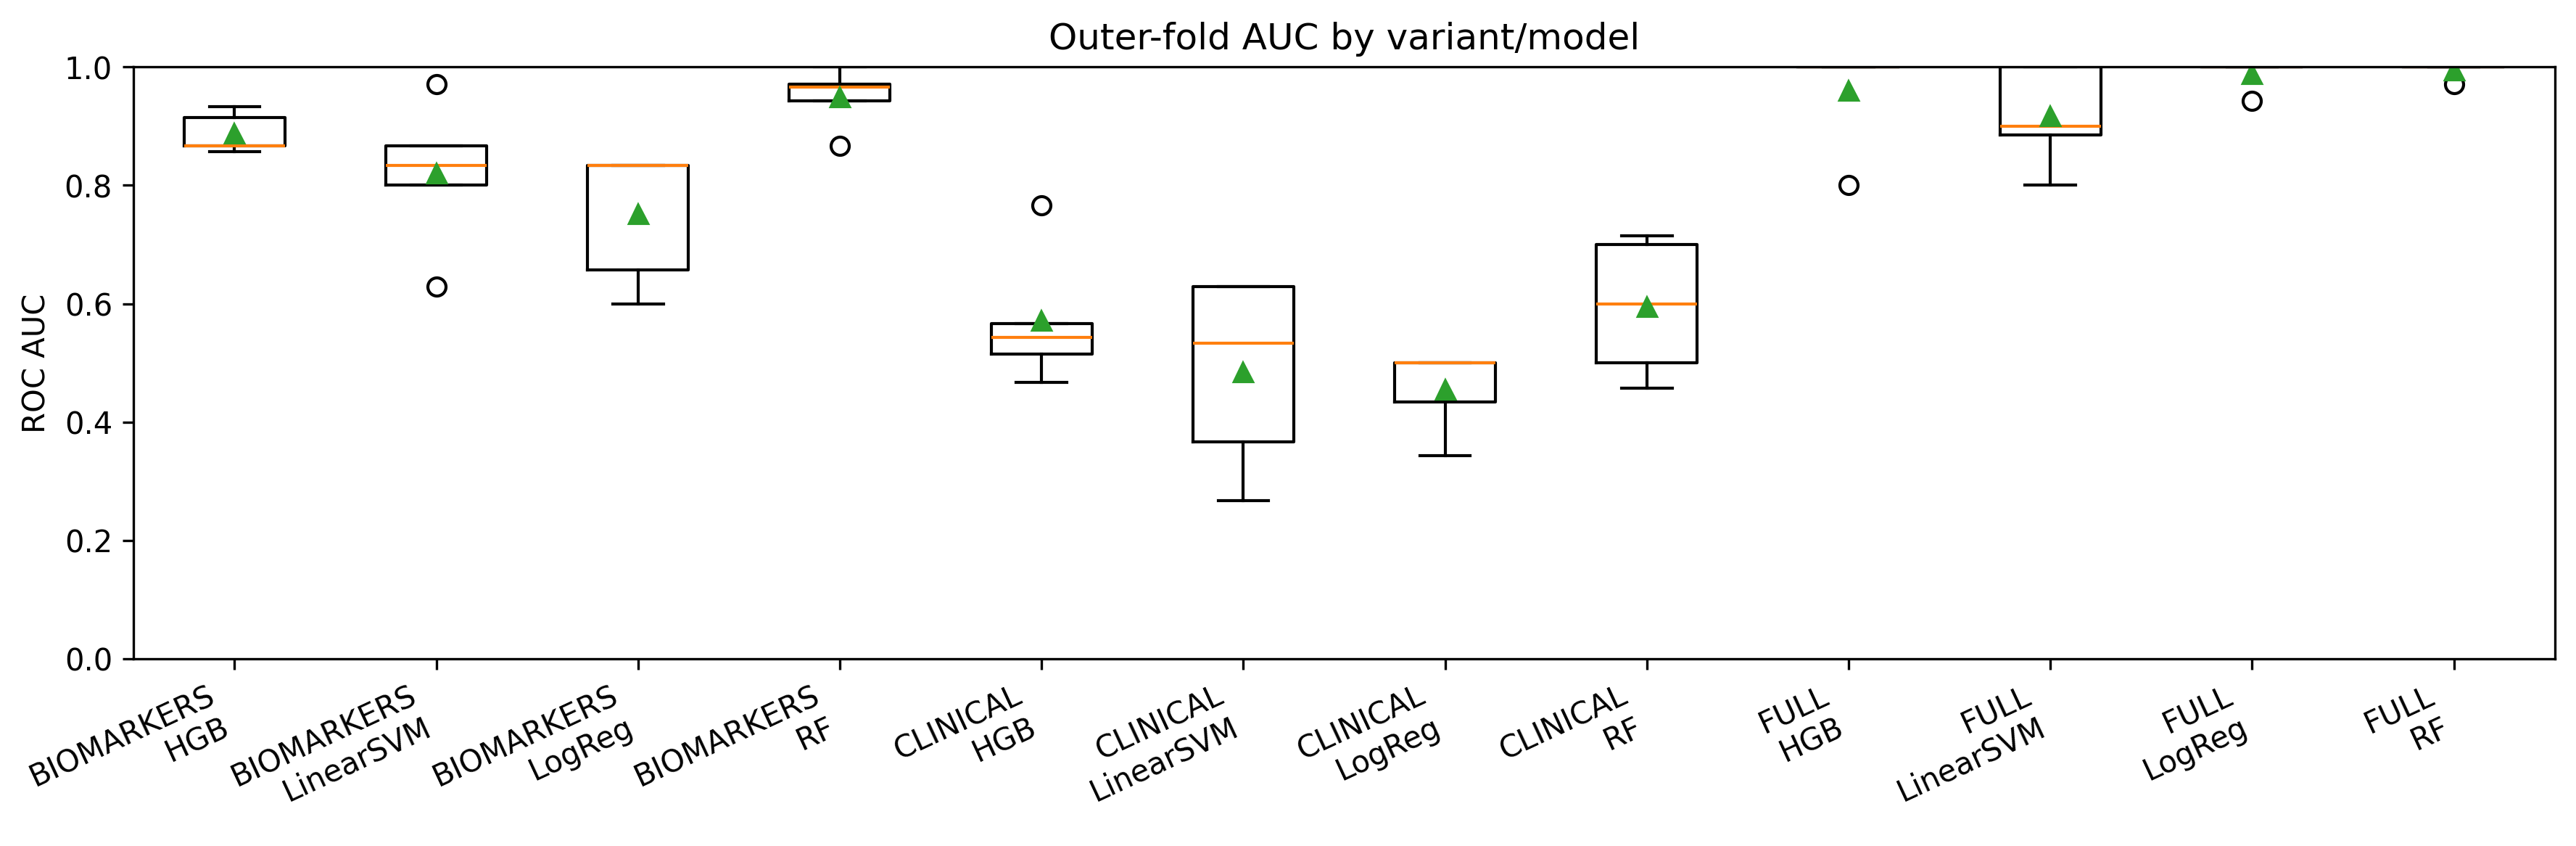

/tmp/ipython-input-2103201746.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, vert=True, showmeans=True)


### Boxplot — AUPRC

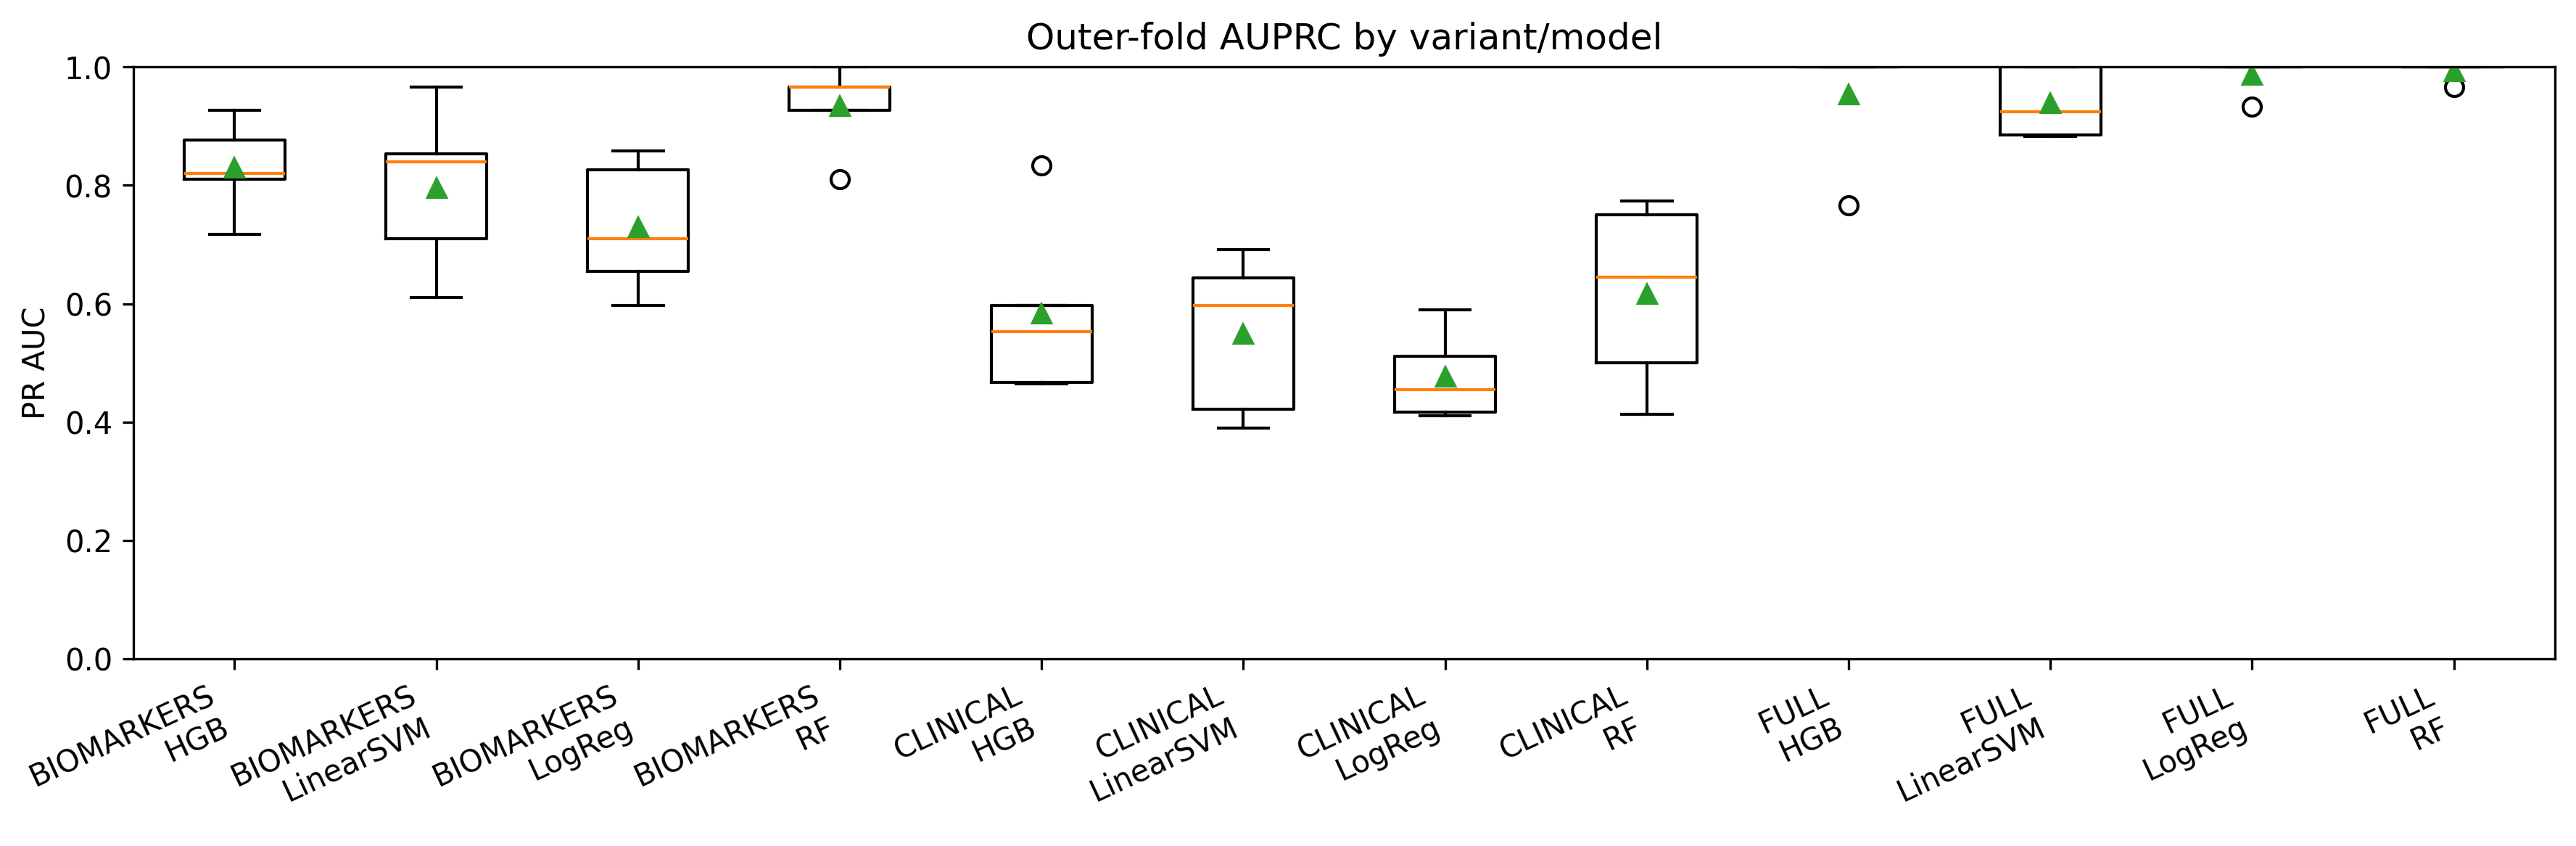

/tmp/ipython-input-2103201746.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, vert=True, showmeans=True)


### Boxplot — BRIER

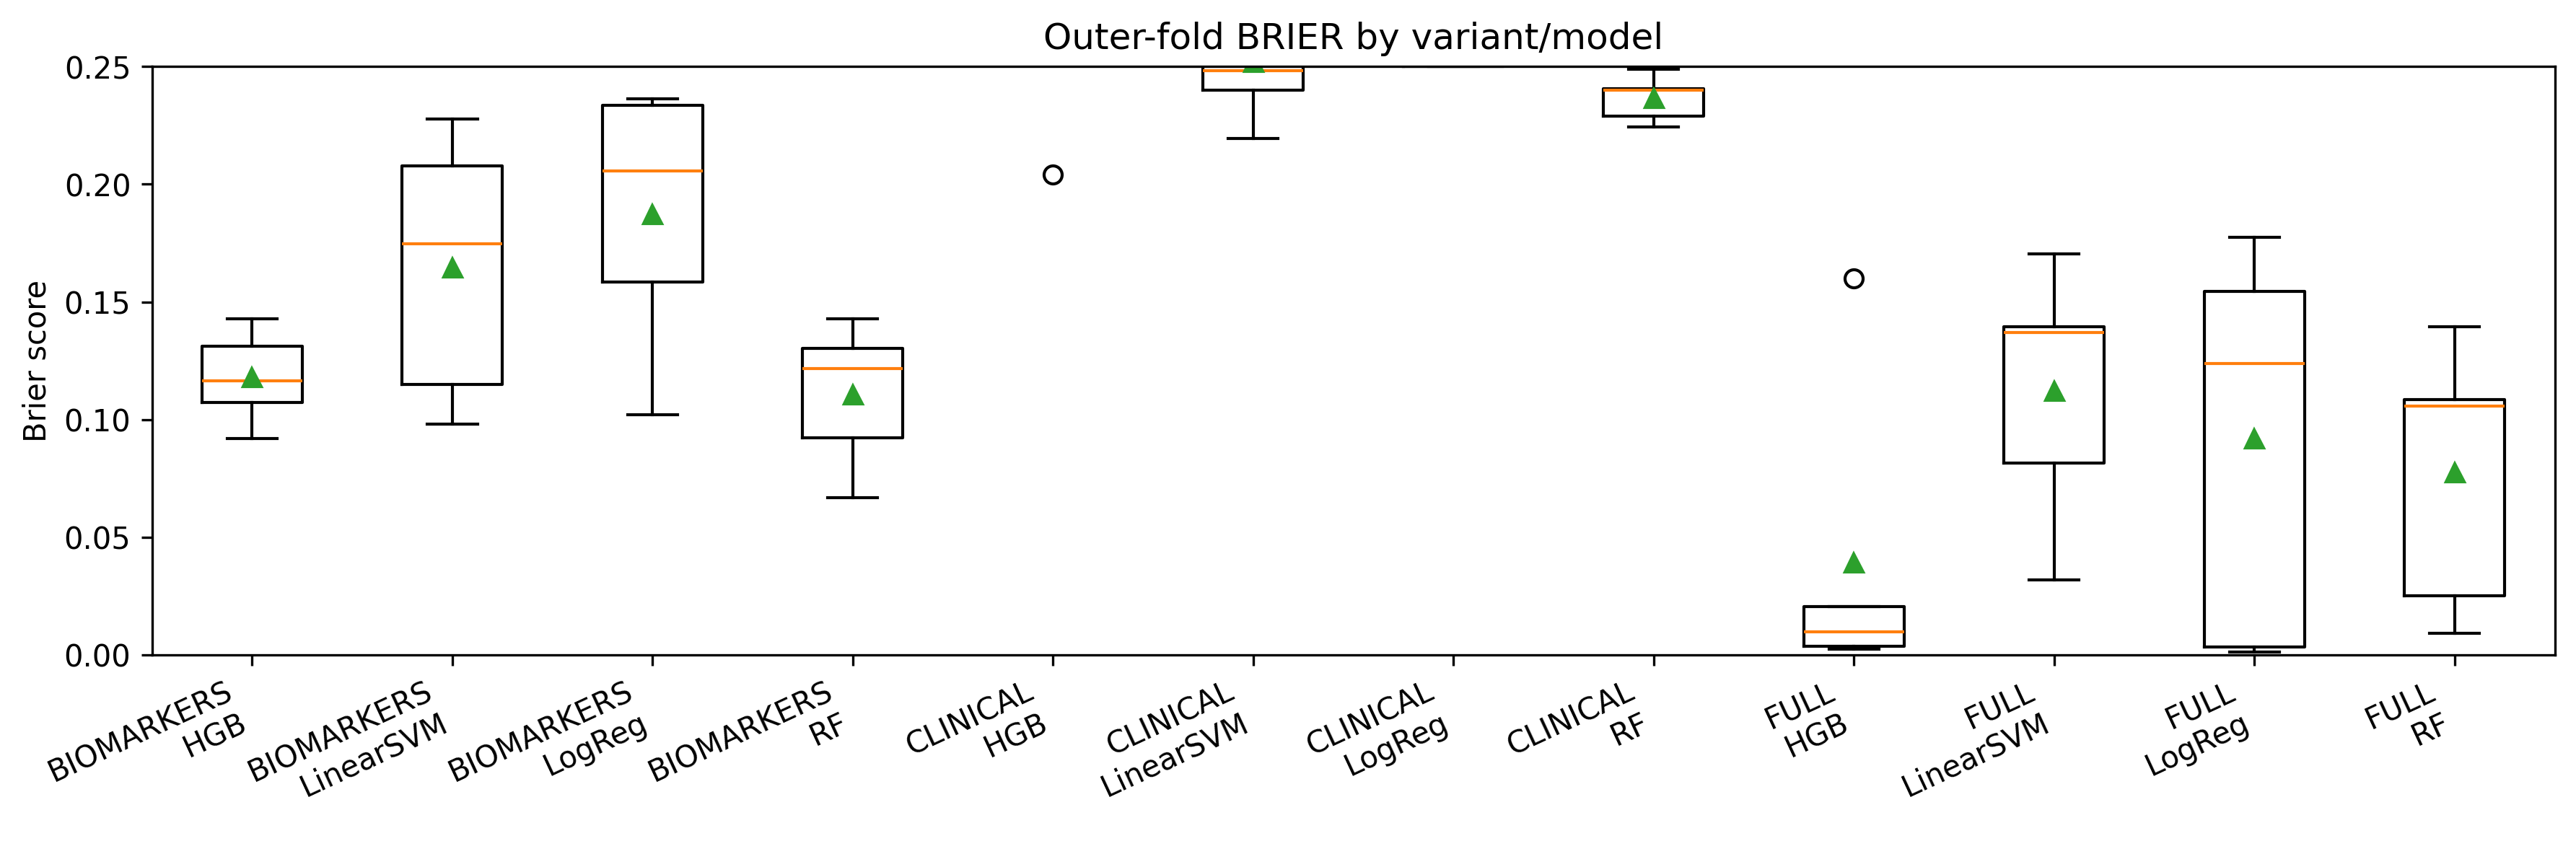

Saved boxplots to: /content/results/S3_benchmark_summary/figures


In [7]:
def savefig(fig: plt.Figure, path: Path, dpi: int = 300) -> None:
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)

def plot_boxplots(results_df: pd.DataFrame, schema: Dict[str, str], fig_dir: Path) -> None:
    var_col, model_col = schema["variant"], schema["model"]
    auc_col, auprc_col = schema["auc"], schema["auprc"]
    brier_col = schema.get("brier", None)

    plots = [("AUC", auc_col), ("AUPRC", auprc_col)]
    if brier_col and brier_col in results_df.columns:
        plots.append(("BRIER", brier_col))

    for label, col in plots:
        groups, labels = [], []
        for (variant, model), g in results_df.groupby([var_col, model_col]):
            vals = g[col].dropna().values
            if len(vals) == 0:
                continue
            groups.append(vals)
            labels.append(f"{variant}\n{model}")

        if not groups:
            continue

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.boxplot(groups, labels=labels, vert=True, showmeans=True)

        metric_ylabel = {"AUC": "ROC AUC", "AUPRC": "PR AUC", "BRIER": "Brier score"}.get(label, col)
        ax.set_title(f"Outer-fold {label} by variant/model")
        ax.set_ylabel(metric_ylabel)

        if label in {"AUC", "AUPRC"}:
            ax.set_ylim(0.0, 1.0)
        elif label == "BRIER":
            all_vals = np.concatenate([np.asarray(g) for g in groups]) if groups else np.array([0.0])
            ymax = float(np.nanmax(all_vals)) * 1.15
            ax.set_ylim(0.0, min(0.25, max(0.05, ymax)))

        ax.tick_params(axis="x", labelrotation=25)
        for tick in ax.get_xticklabels():
            tick.set_ha("right")

        out = fig_dir / f"boxplot_{label.lower()}.png"
        savefig(fig, out)
        _display_image(out, f"Boxplot — {label}")

plot_boxplots(results_df, res_schema, FIGURES_DIR)
print("Saved boxplots to:", FIGURES_DIR)


## Stratified bootstrap CI for winner OOF metrics + ROC/PR plots

### OOF ROC — BIOMARKERS / RF

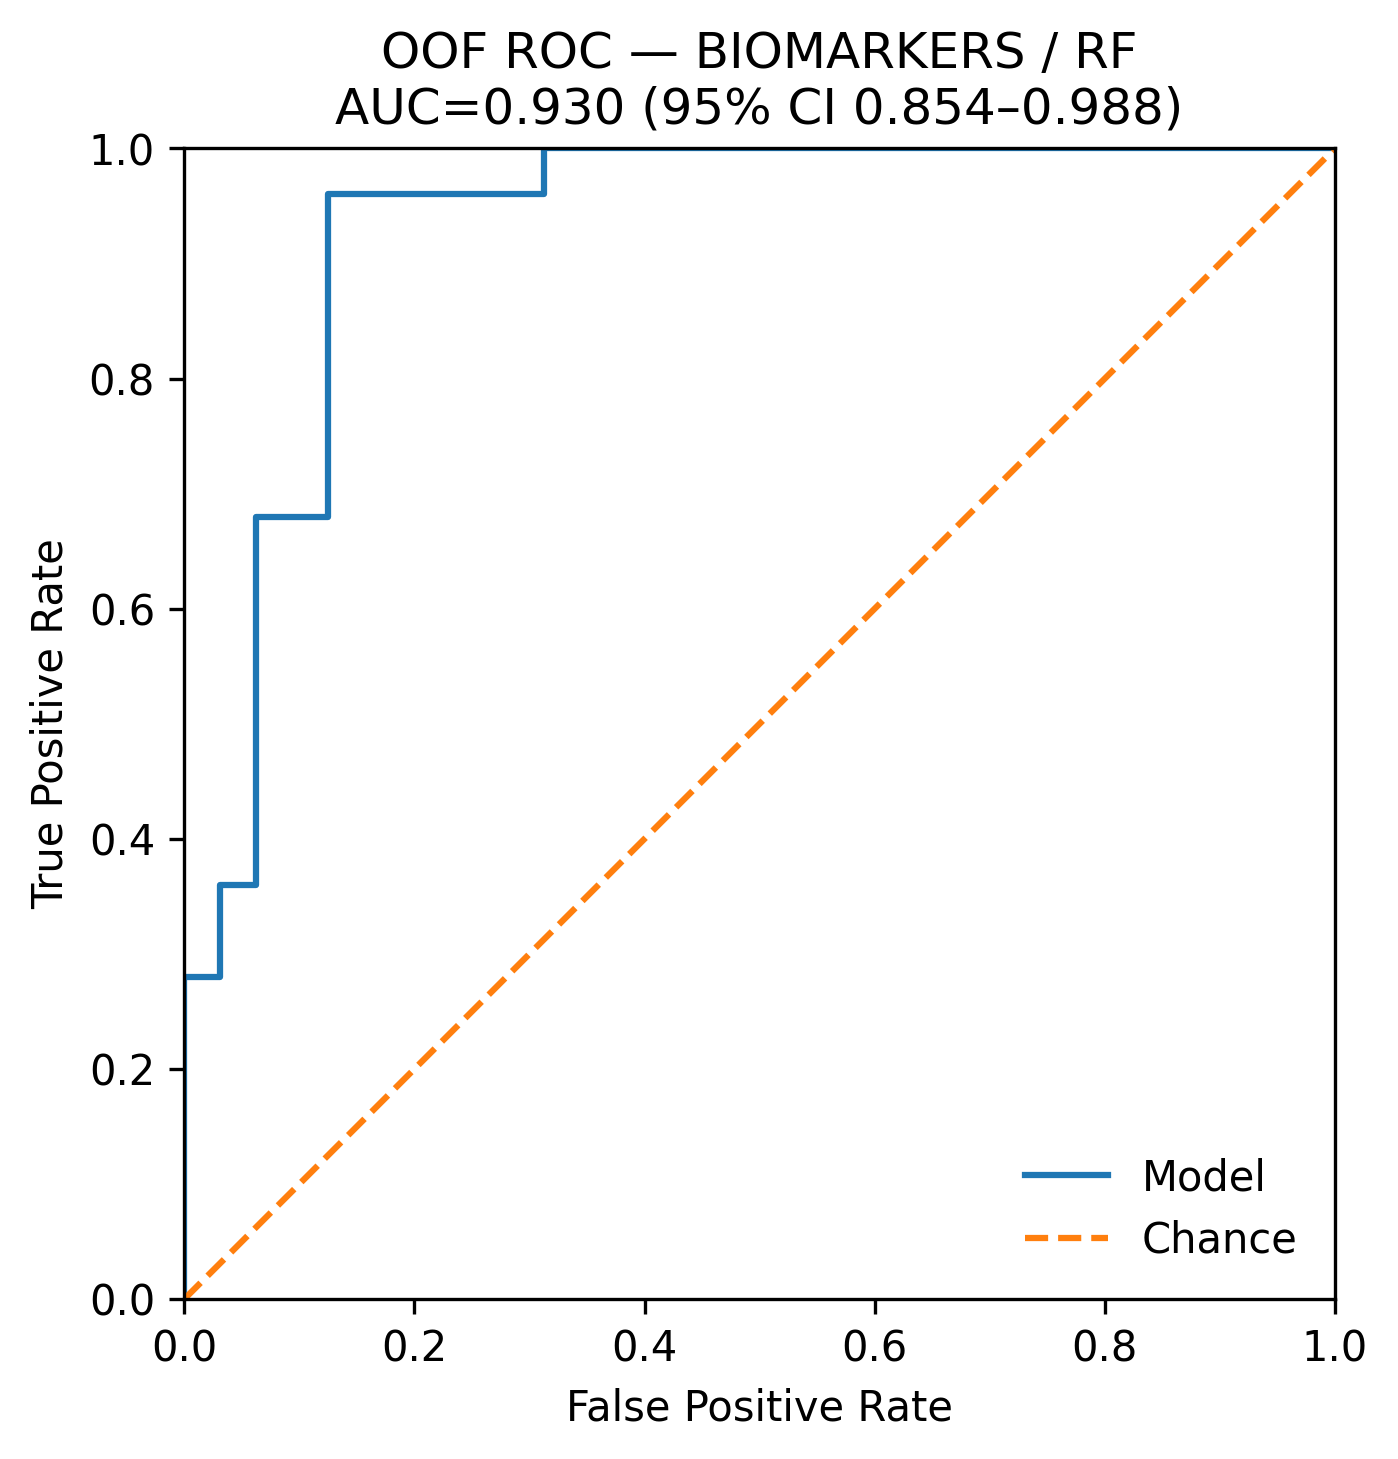

### OOF PR — BIOMARKERS / RF

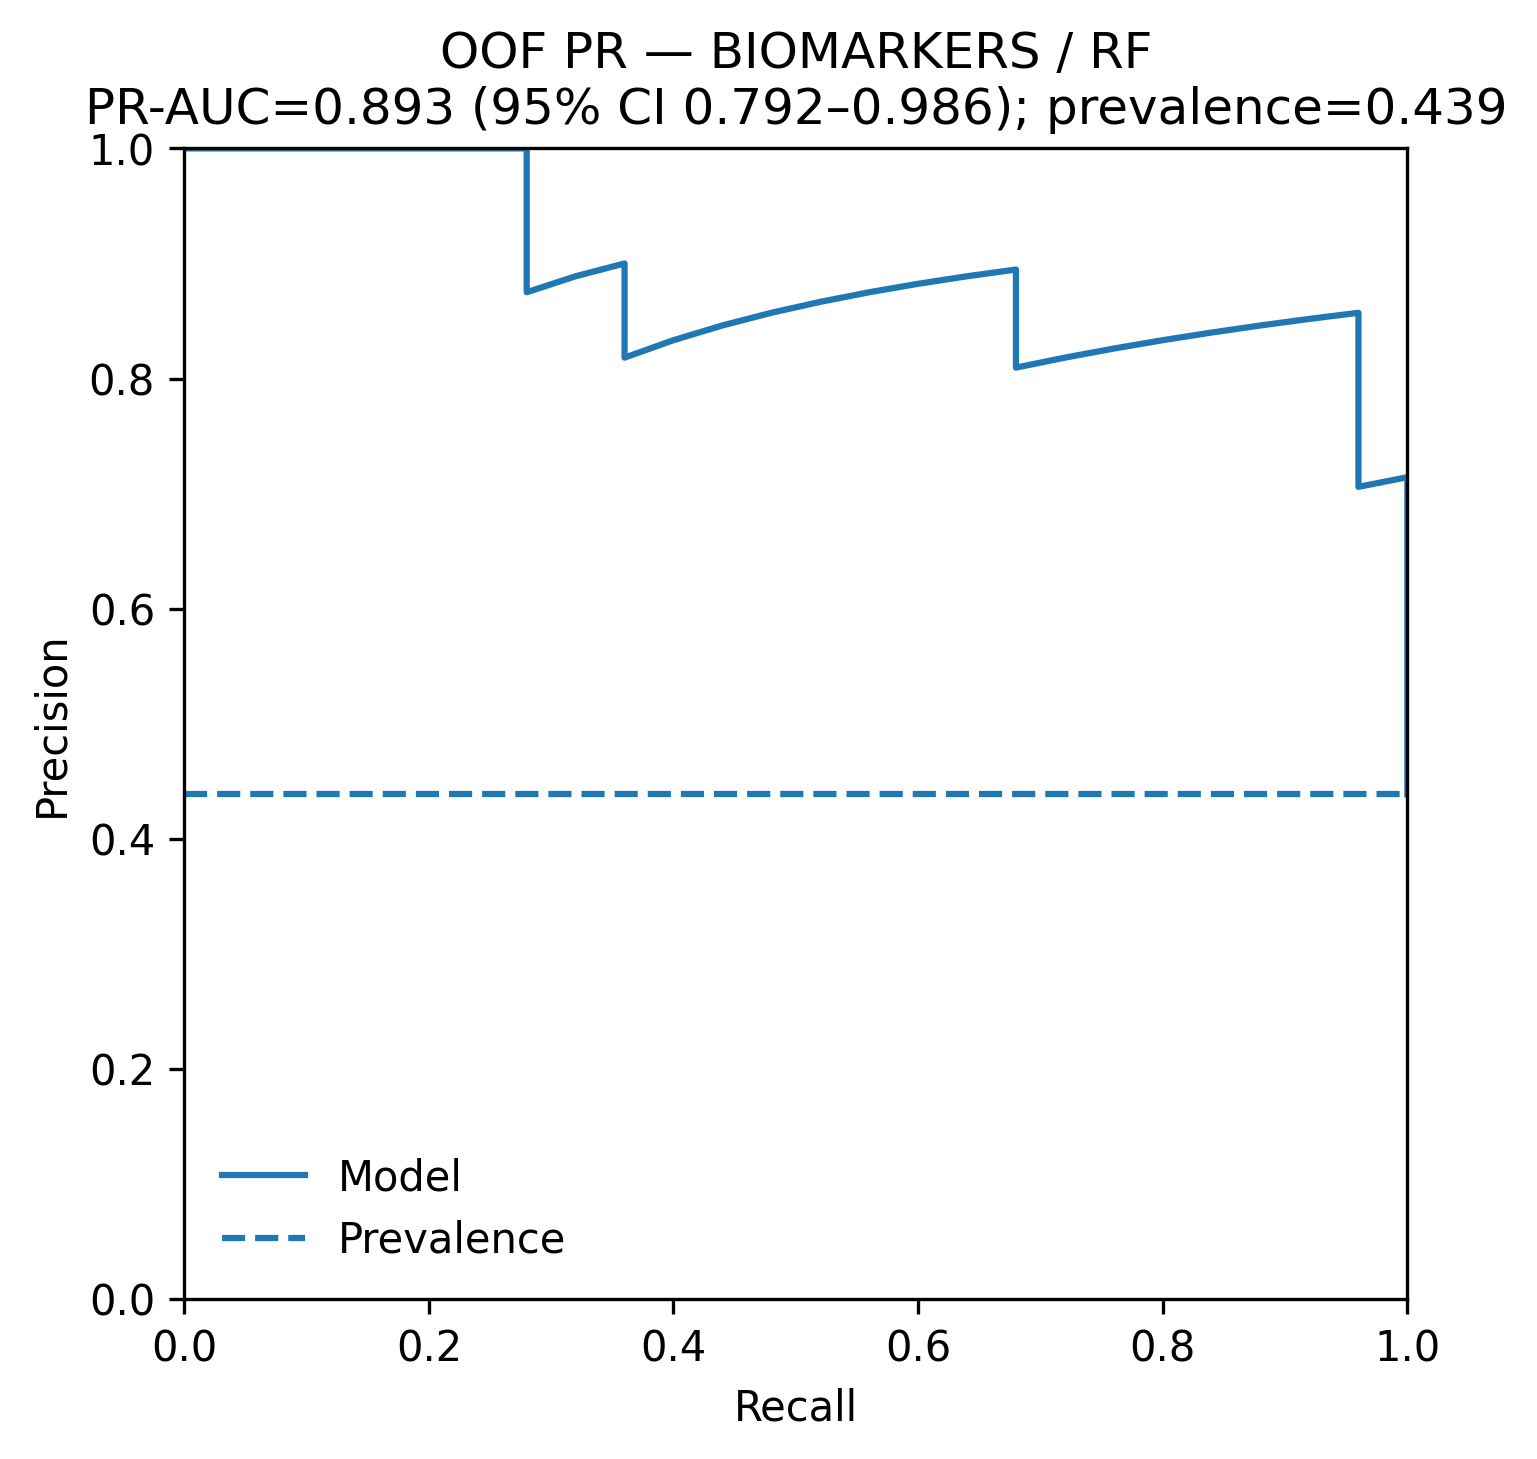

### OOF ROC — CLINICAL / RF

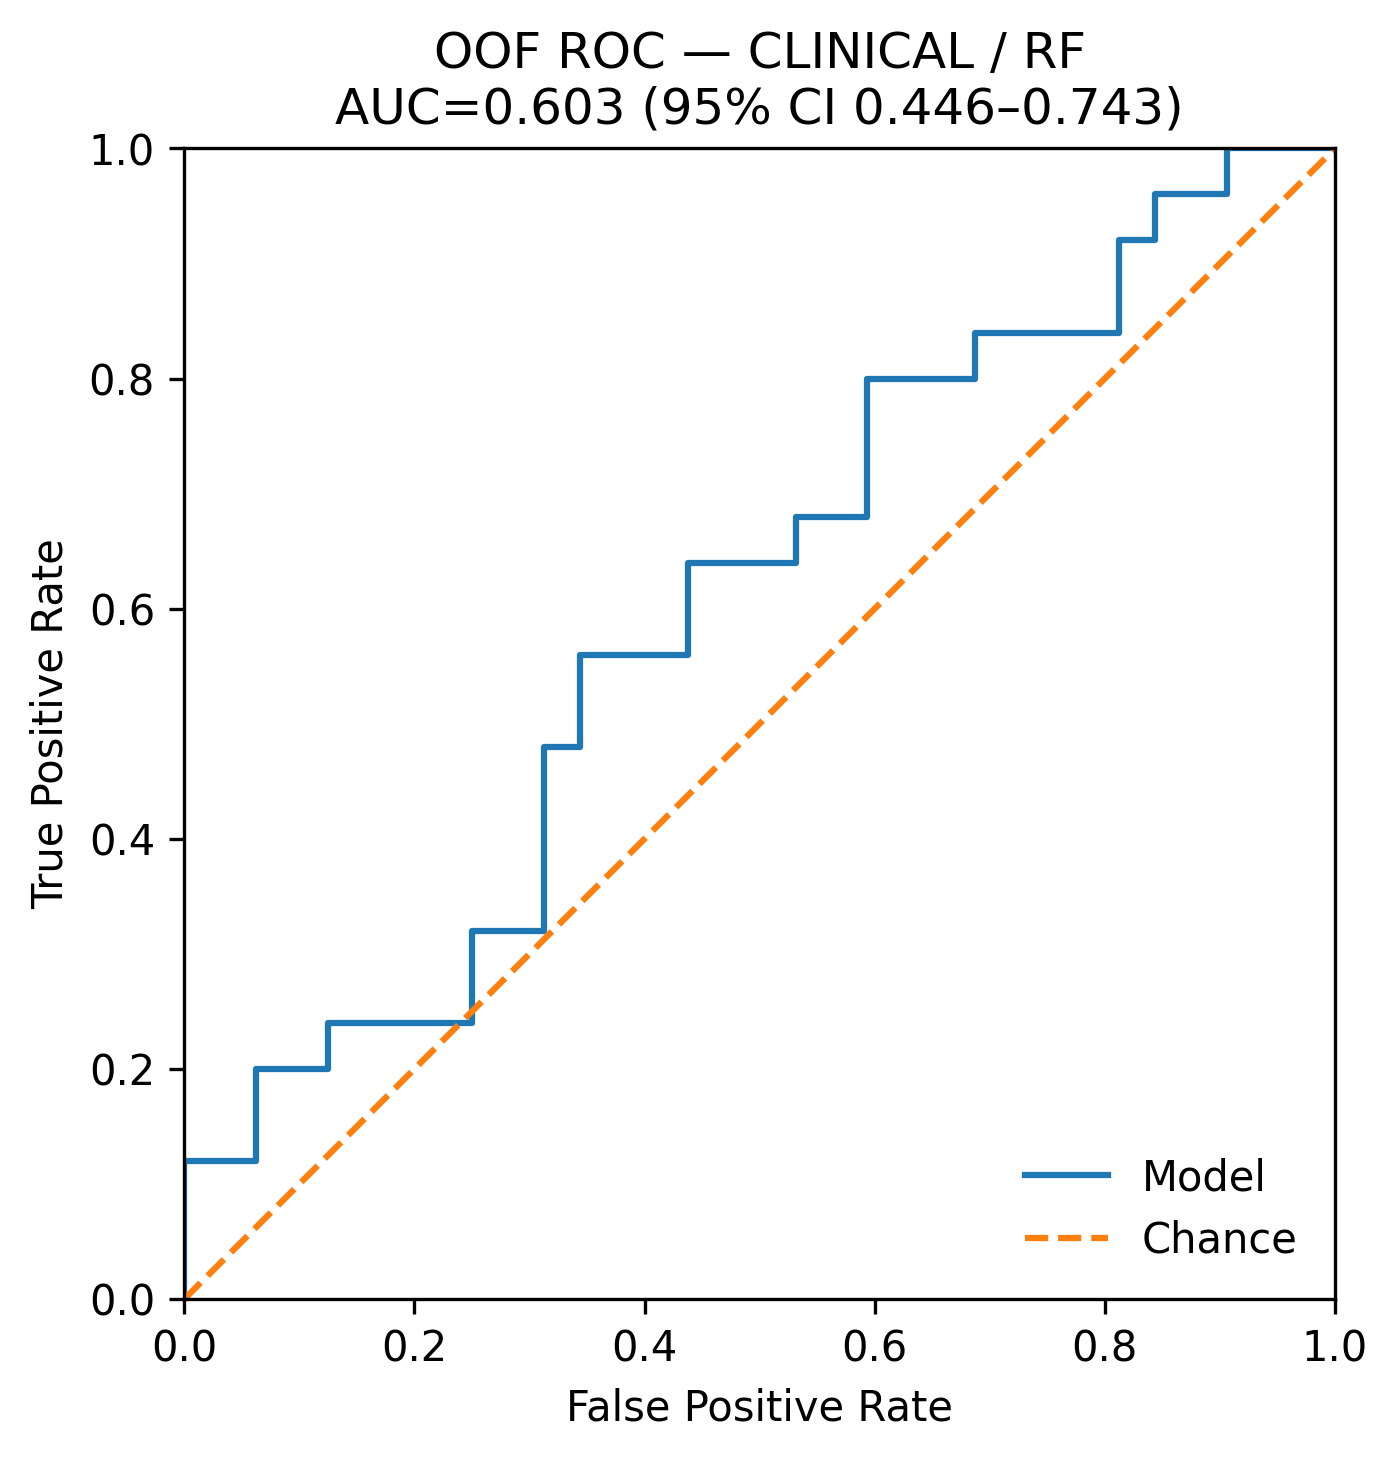

### OOF PR — CLINICAL / RF

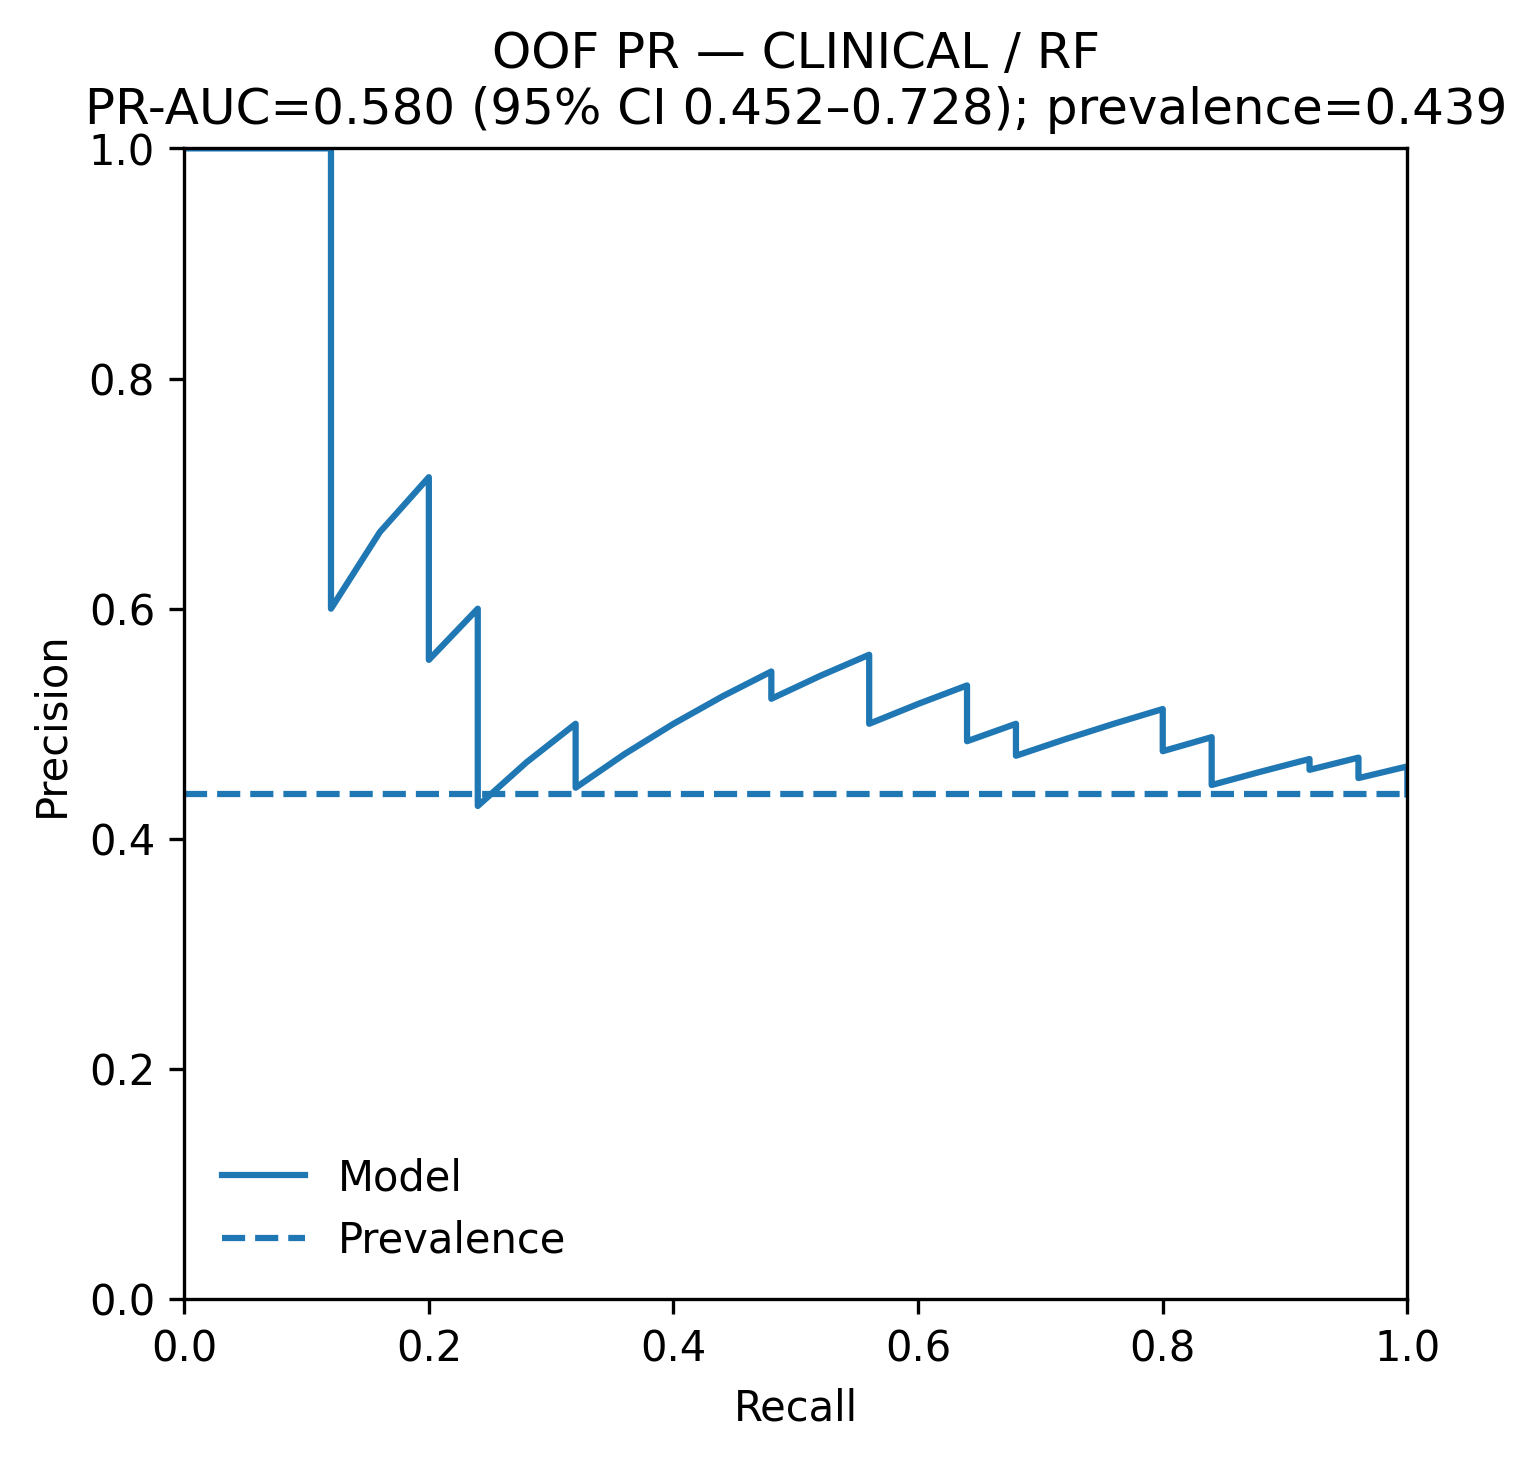

### OOF ROC — FULL / RF

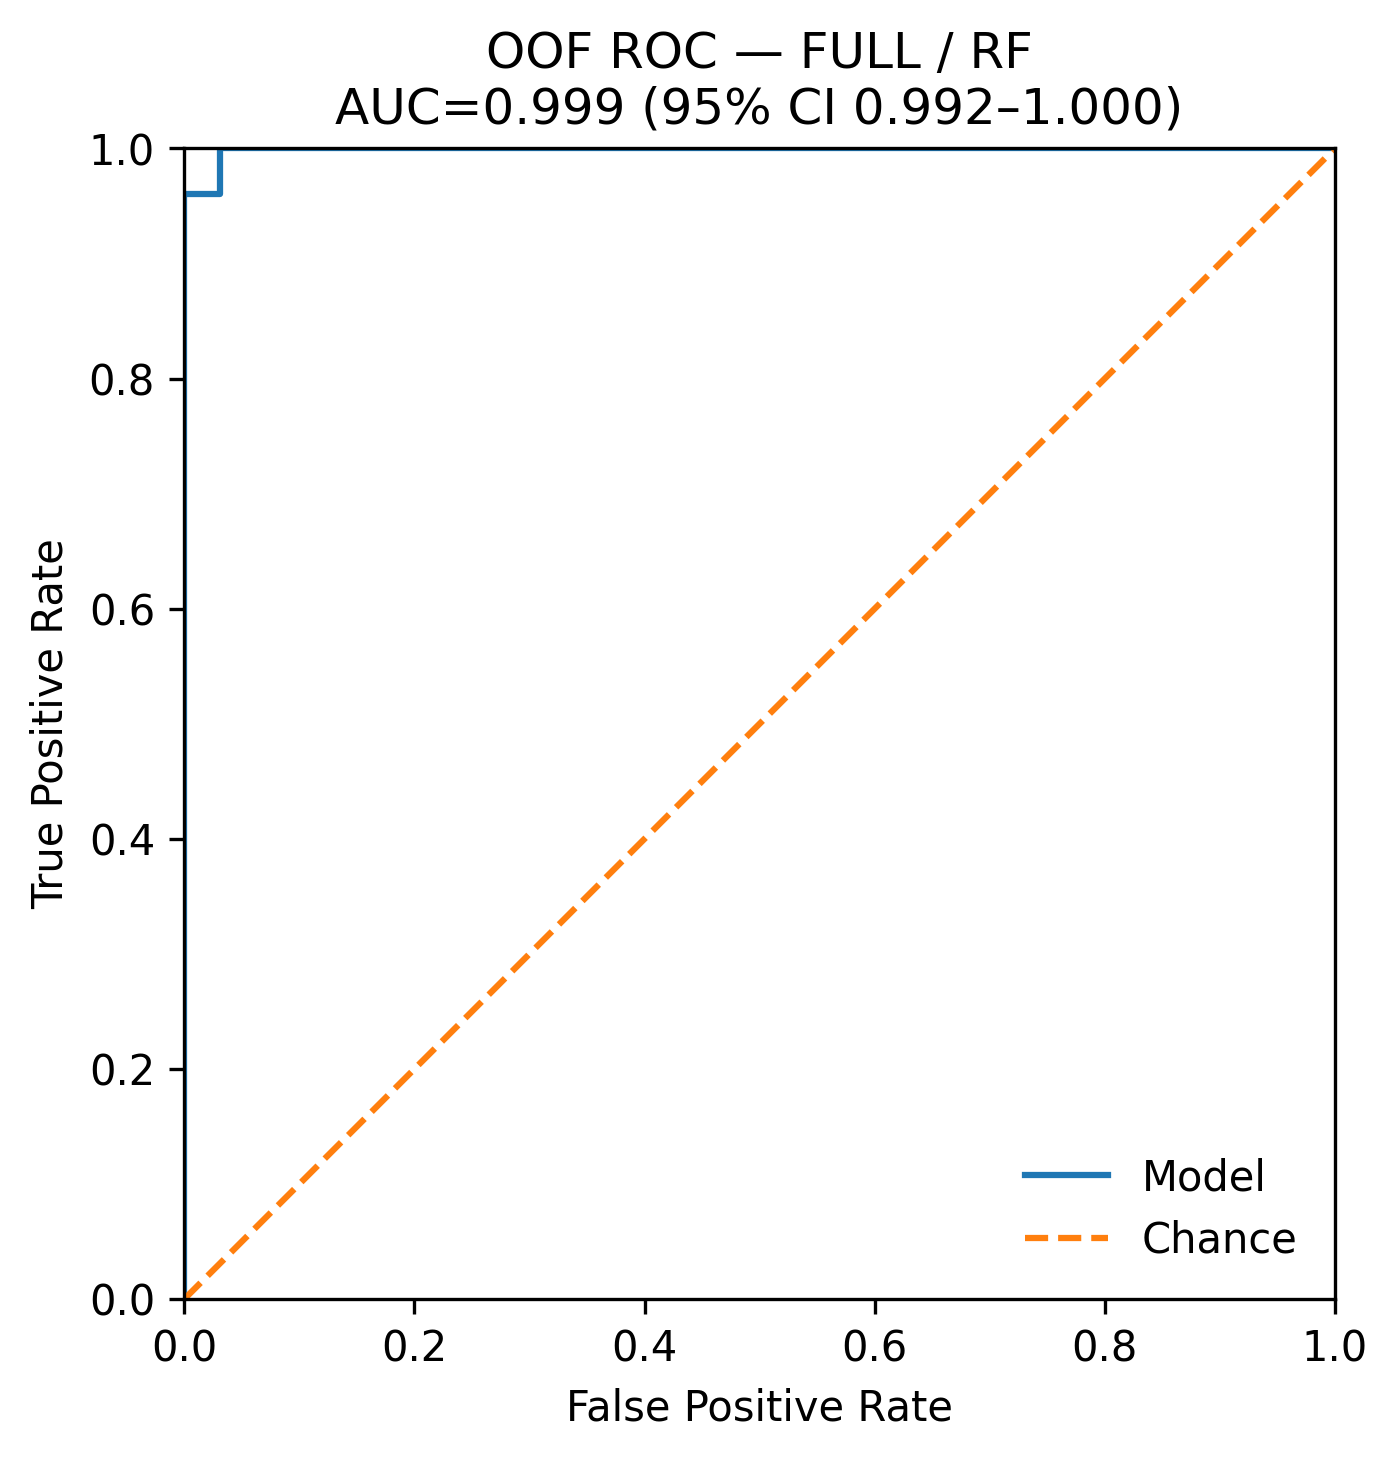

### OOF PR — FULL / RF

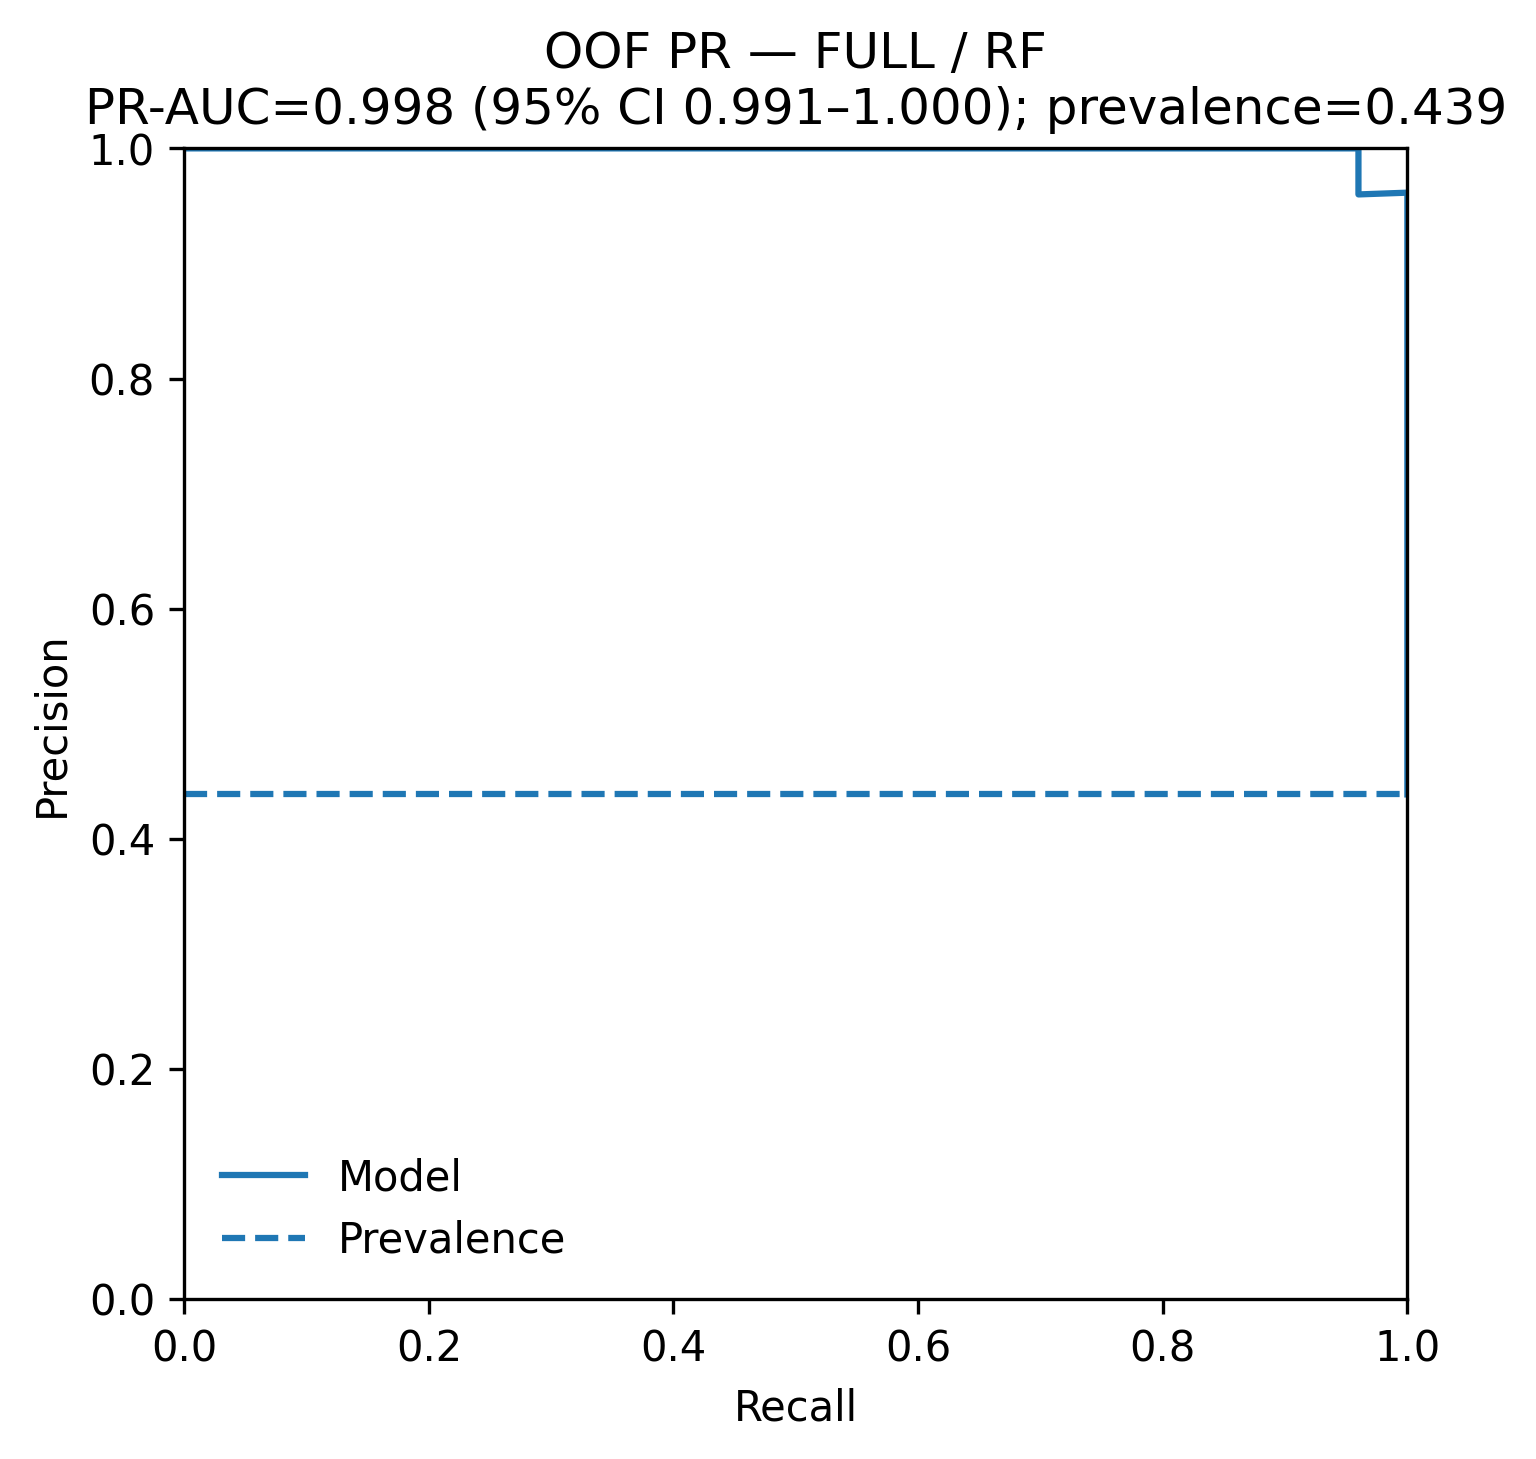

Saved: winner_oof_metrics_with_bootstrap_ci.csv


### Winner OOF metrics (with bootstrap CI)

,variant,winner_model,oof_auc,oof_auc_ci_low,oof_auc_ci_high,oof_auprc,oof_auprc_ci_low,oof_auprc_ci_high,oof_brier,prevalence,n
0,BIOMARKERS,RF,0.93000,0.853719,0.987500,0.892808,0.792385,0.985820,0.111469,0.438596,57
1,CLINICAL,RF,0.60250,0.446250,0.742531,0.579670,0.451827,0.727953,0.236464,0.438596,57
2,FULL,RF,0.99875,0.992500,1.000000,0.998462,0.991429,1.000000,0.077729,0.438596,57


In [8]:
def stratified_bootstrap_ci(
    y_true: np.ndarray,
    y_score: np.ndarray,
    metric_fn,
    n_boot: int = 2000,
    seed: int = 42,
) -> Tuple[float, float, float]:
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    point = float(metric_fn(y_true, y_score))
    idx0 = np.where(y_true == 0)[0]
    idx1 = np.where(y_true == 1)[0]
    n0, n1 = len(idx0), len(idx1)

    boots = []
    for _ in range(n_boot):
        s0 = rng.choice(idx0, size=n0, replace=True)
        s1 = rng.choice(idx1, size=n1, replace=True)
        s = np.concatenate([s0, s1])
        rng.shuffle(s)
        try:
            boots.append(float(metric_fn(y_true[s], y_score[s])))
        except Exception:
            continue

    if len(boots) < 50:
        return point, float("nan"), float("nan")

    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, float(lo), float(hi)

def plot_oof_roc_pr_for_winners(
    oof_df: pd.DataFrame,
    oof_schema: Dict[str, str],
    winners_df: pd.DataFrame,
    fig_dir: Path,
    n_boot: int = 2000,
    seed: int = 42,
) -> pd.DataFrame:
    var_col = oof_schema["variant"]
    model_col = oof_schema["model"]
    y_true_col = oof_schema["y_true"]
    y_prob_col = oof_schema["y_prob"]

    w_var = pick_first_existing(["variant", "Variant"], winners_df.columns) or "variant"
    w_model = pick_first_existing(["model", "Model"], winners_df.columns) or "model"

    rows = []
    for variant in sorted(winners_df[w_var].unique()):
        winner_model = winners_df.loc[winners_df[w_var] == variant, w_model].iloc[0]
        g = oof_df[(oof_df[var_col] == variant) & (oof_df[model_col] == winner_model)].copy()
        if g.empty:
            continue

        y_true = g[y_true_col].to_numpy().astype(int)
        y_prob = g[y_prob_col].to_numpy().astype(float)

        auc_point, auc_lo, auc_hi = stratified_bootstrap_ci(y_true, y_prob, roc_auc_score, n_boot=n_boot, seed=seed)
        ap_point, ap_lo, ap_hi = stratified_bootstrap_ci(y_true, y_prob, average_precision_score, n_boot=n_boot, seed=seed + 1)
        brier = float(brier_score_loss(y_true, y_prob))
        prevalence = float(np.mean(y_true))

        rows.append({
            "variant": variant,
            "winner_model": winner_model,
            "oof_auc": auc_point,
            "oof_auc_ci_low": auc_lo,
            "oof_auc_ci_high": auc_hi,
            "oof_auprc": ap_point,
            "oof_auprc_ci_low": ap_lo,
            "oof_auprc_ci_high": ap_hi,
            "oof_brier": brier,
            "prevalence": prevalence,
            "n": int(len(y_true)),
        })

        # ROC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.plot(fpr, tpr, label="Model")
        ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 1.0)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"OOF ROC — {variant} / {winner_model}\nAUC={auc_point:.3f} (95% CI {auc_lo:.3f}–{auc_hi:.3f})")
        ax.legend(loc="lower right", frameon=False)
        roc_out = fig_dir / f"oof_roc_{variant}_{winner_model}.png"
        savefig(fig, roc_out)
        _display_image(roc_out, f"OOF ROC — {variant} / {winner_model}")

        # PR
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.plot(recall, precision, label="Model")
        ax.hlines(prevalence, xmin=0.0, xmax=1.0, linestyles="--", label="Prevalence")
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 1.0)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(
            f"OOF PR — {variant} / {winner_model}\nPR-AUC={ap_point:.3f} (95% CI {ap_lo:.3f}–{ap_hi:.3f}); prevalence={prevalence:.3f}"
        )
        ax.legend(loc="lower left", frameon=False)
        pr_out = fig_dir / f"oof_pr_{variant}_{winner_model}.png"
        savefig(fig, pr_out)
        _display_image(pr_out, f"OOF PR — {variant} / {winner_model}")

    return pd.DataFrame(rows)

winner_oof_ci = plot_oof_roc_pr_for_winners(oof_df, oof_schema, winners_df, FIGURES_DIR, n_boot=2000, seed=42)

winner_ci_path = TABLES_DIR / "winner_oof_metrics_with_bootstrap_ci.csv"
winner_oof_ci.to_csv(winner_ci_path, index=False)

print("Saved:", winner_ci_path.name)
_display_df(winner_oof_ci, "Winner OOF metrics (with bootstrap CI)", n=50)


## Copy auxiliary tables from S2 (calibration + DCA)

In [9]:
for fn in ["oof_calibration_summary.csv", "oof_calibration_curve.csv", "oof_dca_curves.csv"]:
    p = S2_DIR / fn
    if p.exists():
        out = TABLES_DIR / fn
        pd.read_csv(p).to_csv(out, index=False)
        print("Copied:", fn, "->", out)
    else:
        print("Missing in S2 (skipped):", fn)


Copied: oof_calibration_summary.csv -> /content/results/S3_benchmark_summary/tables/oof_calibration_summary.csv
Copied: oof_calibration_curve.csv -> /content/results/S3_benchmark_summary/tables/oof_calibration_curve.csv
Copied: oof_dca_curves.csv -> /content/results/S3_benchmark_summary/tables/oof_dca_curves.csv


## Save manifest of all outputs (for auditability)

In [10]:
manifest = []
for p in sorted(TABLES_DIR.glob("*.csv")):
    manifest.append({"type": "table", "path": str(p)})
for p in sorted(FIGURES_DIR.glob("*.png")):
    manifest.append({"type": "figure", "path": str(p)})
for p in sorted(LOGS_DIR.glob("*.json")):
    manifest.append({"type": "log", "path": str(p)})

manifest_df = pd.DataFrame(manifest)
manifest_path = LOGS_DIR / "S3_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print("Saved:", manifest_path.name)
_display_df(manifest_df, "S3 manifest (outputs)", n=200)


Saved: S3_manifest.csv


### S3 manifest (outputs)

,type,path
0,table,/content/results/S3_benchmark_summary/tables/f...
1,table,/content/results/S3_benchmark_summary/tables/o...
2,table,/content/results/S3_benchmark_summary/tables/o...
3,table,/content/results/S3_benchmark_summary/tables/o...
4,table,/content/results/S3_benchmark_summary/tables/w...
5,figure,/content/results/S3_benchmark_summary/figures/...
6,figure,/content/results/S3_benchmark_summary/figures/...
7,figure,/content/results/S3_benchmark_summary/figures/...
8,figure,/content/results/S3_benchmark_summary/figures/...
9,figure,/content/results/S3_benchmark_summary/figures/...


## Final sanity checks + quick printout

In [11]:
print("\nS3 completed successfully.")
print("Output root:", OUT_ROOT.resolve())
print("Tables:", len(list(TABLES_DIR.glob("*.csv"))), "| Figures:", len(list(FIGURES_DIR.glob("*.png"))), "| Logs:", len(list(LOGS_DIR.glob("*.json"))))

print("\nKey outputs:")
for p in [
    TABLES_DIR / "fold_metrics_summary_by_variant_model.csv",
    TABLES_DIR / "winner_oof_metrics_with_bootstrap_ci.csv",
    FIGURES_DIR / "boxplot_auc.png",
    FIGURES_DIR / "boxplot_auprc.png",
    FIGURES_DIR / "boxplot_brier.png",
]:
    print(" -", p, "| exists:", p.exists())



S3 completed successfully.
Output root: /content/results/S3_benchmark_summary
Tables: 5 | Figures: 9 | Logs: 1

Key outputs:
 - /content/results/S3_benchmark_summary/tables/fold_metrics_summary_by_variant_model.csv | exists: True
 - /content/results/S3_benchmark_summary/tables/winner_oof_metrics_with_bootstrap_ci.csv | exists: True
 - /content/results/S3_benchmark_summary/figures/boxplot_auc.png | exists: True
 - /content/results/S3_benchmark_summary/figures/boxplot_auprc.png | exists: True
 - /content/results/S3_benchmark_summary/figures/boxplot_brier.png | exists: True
